# Summary Statistics for Founder Education Sample
This notebook provides basic descriptive statistics for the raw founder education list extracted from `Founder_Education_List_[US-2000-2023].csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configure styling to match academic publication standards
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams['font.size'] = 11


In [2]:
file_path = "../../D - Data/D1 - Extracted Datasets/Founder_Education_List_[US-2000-2023].csv"
print("Loading dataset...")
df = pd.read_csv(file_path, low_memory=False)
print(f"Loaded {len(df):,} rows.")


Loading dataset...


Loaded 2,351,237 rows.


In [3]:
print("--- Dataset Information ---")
print(df.info())

print("\n--- Missing Value Counts ---")
print(df.isnull().sum())


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2351237 entries, 0 to 2351236
Data columns (total 16 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   user_id                      int64  
 1   university_raw               object 
 2   university_name              object 
 3   rsid                         float64
 4   education_number             int64  
 5   startdate                    object 
 6   enddate                      object 
 7   degree                       object 
 8   field                        object 
 9   degree_raw                   object 
 10  field_raw                    object 
 11  university_country           object 
 12  university_location          object 
 13  ultimate_parent_school_name  object 
 14  ultimate_parent_rsid         float64
 15  description                  object 
dtypes: float64(2), int64(2), object(12)
memory usage: 287.0+ MB
None

--- Missing Value Counts ---


user_id                              0
university_raw                    1121
university_name                 273204
rsid                            256784
education_number                     0
startdate                       483682
enddate                         514422
degree                               0
field                                0
degree_raw                      484454
field_raw                       572156
university_country              298273
university_location             833764
ultimate_parent_school_name     273204
ultimate_parent_rsid            273204
description                    1646939
dtype: int64


In [4]:
print(f"Unique individuals (user_id): {df['user_id'].nunique():,}")
print(f"Unique schools (university_name): {df['university_name'].nunique():,}")


Unique individuals (user_id): 987,658
Unique schools (university_name): 38,917


--- Frequency of Pre-Classified Degrees ---
degree
empty          919259
Bachelor       783842
Master         262434
MBA            129141
Doctor          98748
High School     92676
Associate       65137
Name: count, dtype: int64


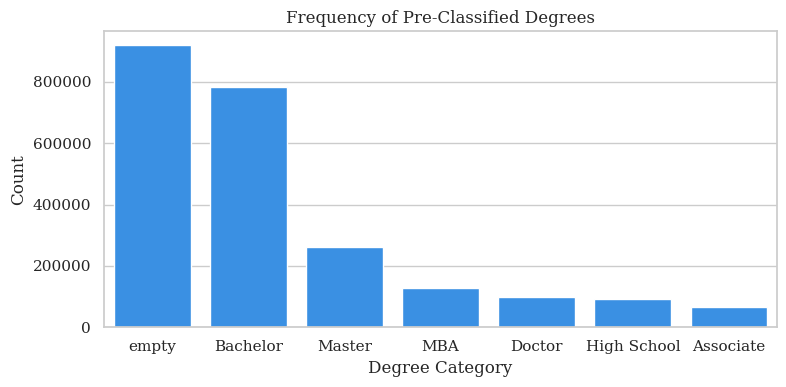

In [5]:
print("--- Frequency of Pre-Classified Degrees ---")
deg_counts = df['degree'].value_counts(dropna=False)
print(deg_counts)

plt.figure(figsize=(8, 4))
# Use unified dodgerblue to match the career advancement levels figure
sns.barplot(x=deg_counts.index.astype(str), y=deg_counts.values, color="dodgerblue")
plt.title("Frequency of Pre-Classified Degrees")
plt.ylabel("Count")
plt.xlabel("Degree Category")
plt.tight_layout()
plt.show()


--- Start Year Statistics ---
count    1.867116e+06
mean     2.004908e+03
std      1.268805e+01
min      1.950000e+03
25%      1.997000e+03
50%      2.007000e+03
75%      2.015000e+03
max      2.026000e+03
Name: start_yr, dtype: float64

--- End Year Statistics ---
count    1.823294e+06
mean     2.007497e+03
std      1.223466e+01
min      1.950000e+03
25%      2.000000e+03
50%      2.010000e+03
75%      2.017000e+03
max      2.026000e+03
Name: end_yr, dtype: float64


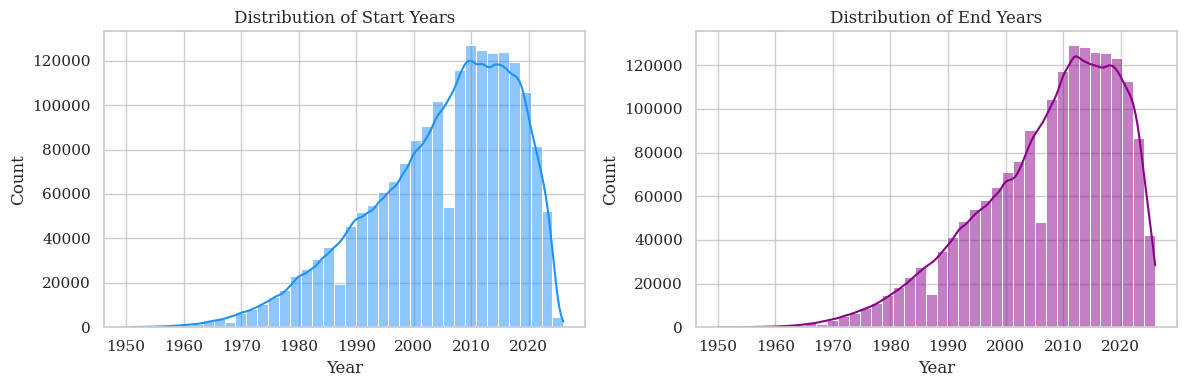

In [6]:
def parse_year(val):
    if pd.isnull(val):
        return np.nan
    val_str = str(val).strip()
    if len(val_str) >= 4 and val_str[:4].isdigit():
        yr = int(val_str[:4])
        if 1950 <= yr <= 2026:
            return yr
    return np.nan

df['start_yr'] = df['startdate'].apply(parse_year)
df['end_yr'] = df['enddate'].apply(parse_year)

print("--- Start Year Statistics ---")
print(df['start_yr'].describe())
print("\n--- End Year Statistics ---")
print(df['end_yr'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Plot start year in dodgerblue and end year in darkmagenta
sns.histplot(df['start_yr'].dropna(), bins=40, ax=axes[0], color='dodgerblue', kde=True)
axes[0].set_title("Distribution of Start Years")
axes[0].set_xlabel("Year")

sns.histplot(df['end_yr'].dropna(), bins=40, ax=axes[1], color='darkmagenta', kde=True)
axes[1].set_title("Distribution of End Years")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()


In [7]:
print("--- Top 20 Raw Degree Titles (degree_raw) ---")
print(df['degree_raw'].value_counts().head(20))


--- Top 20 Raw Degree Titles (degree_raw) ---
degree_raw
Bachelor's degree                            95091
BA                                           63449
Bachelor of Science - BS                     59160
BS                                           55032
Bachelor of Arts - BA                        46405
MBA                                          44487
Bachelor of Arts (B.A.)                      40426
High School Diploma                          38140
Master's degree                              33088
Bachelor’s Degree                            32185
Bachelor of Science (B.S.)                   28475
Master of Business Administration - MBA      27743
Bachelor of Science (BS)                     26276
Bachelor of Science                          25206
Master of Science - MS                       23311
Bachelor's Degree                            22936
Certificate                                  22431
B.A.                                         20107
B.S.                     

In [8]:
print("--- Top 20 Universities (university_name) ---")
print(df['university_name'].value_counts().head(20))


--- Top 20 Universities (university_name) ---
university_name
Stanford University                                         20369
University of California Berkeley                           20101
New York University                                         15109
Harvard University                                          14616
University of California Los Angeles                        13806
Massachusetts Institute of Technology                       13682
University of Southern California                           13658
Cornell University                                          13339
The University of Texas at Austin                           13140
University of Michigan                                      11935
Harvard Business School                                     11816
Columbia University in the City of New York                 10860
University of Washington                                    10782
University of Pennsylvania                                   9696
University of 